In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

connect = pd.read_csv('Connect.csv')
applicant = pd.read_csv('Applicant.csv')
sevis = pd.read_csv('Sevis.csv')


In [ ]:
datasets = {
    "Connect": connect,
    "Applicant": applicant,
    "Sevis": sevis
}

# for easy looping

In [ ]:
# dataset overview
for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print("-" * 40)
    print("Shape:", df.shape)
    print(df.dtypes)


Connect Dataset
----------------------------------------
Shape: (34341, 8)
Reference_ID        int64
Deposit_Status     object
Assigned           object
Recieved_At        object
University         object
I_20_Status        object
Created_At        float64
Modified_At       float64
dtype: object

Applicant Dataset
----------------------------------------
Shape: (34341, 24)
Reference_ID                      int64
Bank_Statement                  float64
Sponsor_Letter                  float64
Passport                        float64
Deposit_Status                   object
Total_Funding_Amt               float64
Cost_To_Issue_I-20              float64
Main_Status                     float64
Assigned                         object
Recieved_At                      object
University                       object
Date_of_Review                  float64
Addtl_Financial                 float64
Tuition_and_Fees                float64
Est_books_supplies_insurance    float64
Est_Living_Expenses    

In [ ]:
# preview data
for name, df in datasets.items():
    print(f"\n{name} Preview")
    print(df.head())


Connect Preview
   Reference_ID Deposit_Status  \
0       1320577            Yes   
1       1356800            Yes   
2       1356915            Yes   
3       1319991            Yes   
4       1266321            Yes   

                                            Assigned      Recieved_At  \
0  Anna Kluemke, Mounika Bhuvana Maheswari Krishn...  4/14/2025 19:55   
1       Catherine Donahue, Jorge Jesus Pena Cevallos  4/14/2025 19:55   
2                                      Ryan Stoeckel  4/14/2025 19:55   
3  Anna Kluemke, Mounika Bhuvana Maheswari Krishn...  4/14/2025 19:55   
4                     Naresh Dama, Catherine Donahue  4/14/2025 19:55   

               University I_20_Status    Created_At   Modified_At  
0  Saint Louis University         Yes  1.740000e+12  1.740000e+12  
1  Saint Louis University         Yes  1.740000e+12  1.740000e+12  
2  Saint Louis University         Yes  1.740000e+12  1.740000e+12  
3  Saint Louis University         Yes  1.740000e+12  1.740000e+12  

In [ ]:
# missing values
for name, df in datasets.items():
    print(f"\n{name} Missing Values")

    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().mean() * 100)

    summary = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing %': missing_percent
    })

    print(summary[summary['Missing Count'] > 0])


Connect Missing Values
          Missing Count  Missing %
Assigned          19810  57.686148

Applicant Missing Values
                              Missing Count   Missing %
Bank_Statement                        34341  100.000000
Sponsor_Letter                        34341  100.000000
Passport                              34341  100.000000
Total_Funding_Amt                     34341  100.000000
Cost_To_Issue_I-20                    34341  100.000000
Main_Status                           34341  100.000000
Assigned                              19810   57.686148
Date_of_Review                        34341  100.000000
Addtl_Financial                       34341  100.000000
Tuition_and_Fees                      34341  100.000000
Est_books_supplies_insurance          34341  100.000000
Est_Living_Expenses                   34341  100.000000
Total_Scholarship                     34341  100.000000
Deposit_Date                          34341  100.000000
English_Language_Requirement          34

In [ ]:
# duplicates
for name, df in datasets.items():
    print(f"{name} duplicate rows:", df.duplicated().sum())

Connect duplicate rows: 0
Applicant duplicate rows: 0
Sevis duplicate rows: 0


In [ ]:
# duplicate check on key
print("Applicant Reference_ID duplicates:", applicant['Reference_ID'].duplicated().sum())
print("Connect Reference_ID duplicates:", connect['Reference_ID'].duplicated().sum())

Applicant Reference_ID duplicates: 27466
Connect Reference_ID duplicates: 27466


In [ ]:
# clean duplicates
applicant_clean = applicant.drop_duplicates(subset='Reference_ID').copy()
connect_clean = connect.drop_duplicates(subset='Reference_ID').copy()

In [ ]:
# clean strings
for df in [applicant_clean, connect_clean, sevis]:
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()

In [ ]:
# dates conversion
for df in [applicant_clean, connect_clean, sevis]:
    for col in df.columns:
        if 'date' in col.lower() or 'created' in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')

/tmp/ipykernel_12960/1230125288.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_12960/1230125288.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_12960/1230125288.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

In [ ]:
#standardize categories
if 'Deposit_Status' in applicant_clean.columns:
    applicant_clean['Deposit_Status'] = applicant_clean['Deposit_Status'].str.upper()

if 'Deposit_Status' in connect_clean.columns:
    connect_clean['Deposit_Status'] = connect_clean['Deposit_Status'].str.upper()

/tmp/ipykernel_12960/1998672534.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  applicant_clean['Deposit_Status'] = applicant_clean['Deposit_Status'].str.upper()
/tmp/ipykernel_12960/1998672534.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  connect_clean['Deposit_Status'] = connect_clean['Deposit_Status'].str.upper()


In [ ]:
# merge applicant + connect
merged = applicant_clean.merge(connect_clean, on='Reference_ID', how='left')

print("Merged shape:", merged.shape)

Merged shape: (6875, 31)


In [ ]:
# sevis integration check
set(applicant.columns).intersection(set(sevis.columns))

{'Created_At', 'Modified_At'}

In [ ]:
# rename duplicate columns
merged = merged.rename(columns={
    'Deposit_Status_x': 'Deposit_Status',
    'Assigned_x': 'Assigned'
})

In [ ]:
# validate merge
print("Applicant_clean rows:", applicant_clean.shape[0])
print("Merged rows:", merged.shape[0])

Applicant_clean rows: 6875
Merged rows: 6875


In [ ]:
# check missing values
merged.isnull().sum().sort_values(ascending=False).head(20)

,0
Bank_Statement,6875
Sponsor_Letter,6875
Passport,6875
Cost_To_Issue_I-20,6875
Total_Funding_Amt,6875
Tuition_and_Fees,6875
Main_Status,6875
Est_books_supplies_insurance,6875
Date_of_Review,6875
Addtl_Financial,6875


In [ ]:
# missing percentage
(merged.isnull().mean() * 100).sort_values(ascending=False).head(20)

,0
Bank_Statement,100.000000
Sponsor_Letter,100.000000
Passport,100.000000
Cost_To_Issue_I-20,100.000000
Total_Funding_Amt,100.000000
Tuition_and_Fees,100.000000
Main_Status,100.000000
Est_books_supplies_insurance,100.000000
Date_of_Review,100.000000
Addtl_Financial,100.000000


In [ ]:
# eligibility distribution
merged['I_20_Status'].value_counts()

,count
I_20_Status,
No,4485
Yes,2390


In [ ]:
# eligibility percentage
merged['I_20_Status'].value_counts(normalize=True) * 100

,proportion
I_20_Status,
No,65.236364
Yes,34.763636


In [ ]:
# deposit distrbituon
merged['Deposit_Status'].value_counts()

,count
Deposit_Status,
NO,5363
YES,1512


In [ ]:
# deposit percentage
merged['Deposit_Status'].value_counts(normalize=True) * 100

,proportion
Deposit_Status,
NO,78.007273
YES,21.992727


In [ ]:
# assigned top values
merged['Assigned'].value_counts().head(10)

,count
Assigned,
"Catherine Donahue, Prince Tetteh",380
"Catherine Donahue, Palak Joshi",234
Prince Tetteh,196
"Alexander Mikhailov, Prince Tetteh",123
"Aaron Greenberg, Prince Tetteh",96
"Victoria Dieckman, Prince Tetteh",92
Aliia Raitova,66
"Anna Kluemke, Prince Tetteh",65
Palak Joshi,59


In [ ]:
# check relationships
merged.groupby('Deposit_Status')['I_20_Status'].value_counts()

Deposit_Status  I_20_Status
NO              No             4224
                Yes            1139
YES             Yes            1251
                No              261
Name: count, dtype: int64

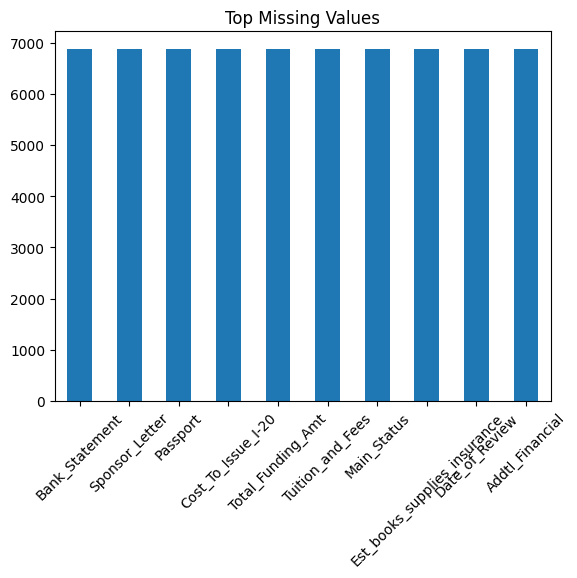

In [ ]:
# visualize missing values
missing = merged.isnull().sum().sort_values(ascending=False).head(10)

missing.plot(kind='bar')
plt.title("Top Missing Values")
plt.xticks(rotation=45)
plt.show()